實驗資料夾： .\MT-GSGCN-CBAM
找到檔案：
   train_curve_human1.csv
   train_curve_human2.csv
   train_curve_human3.csv
   train_curve_human4.csv
   train_curve_human5.csv
   train_curve_human6.csv
   train_curve_human7.csv
   train_curve_human8.csv
   train_curve_human9.csv
   train_curve_human10.csv
Loaded 10 folds, 80 epochs each.


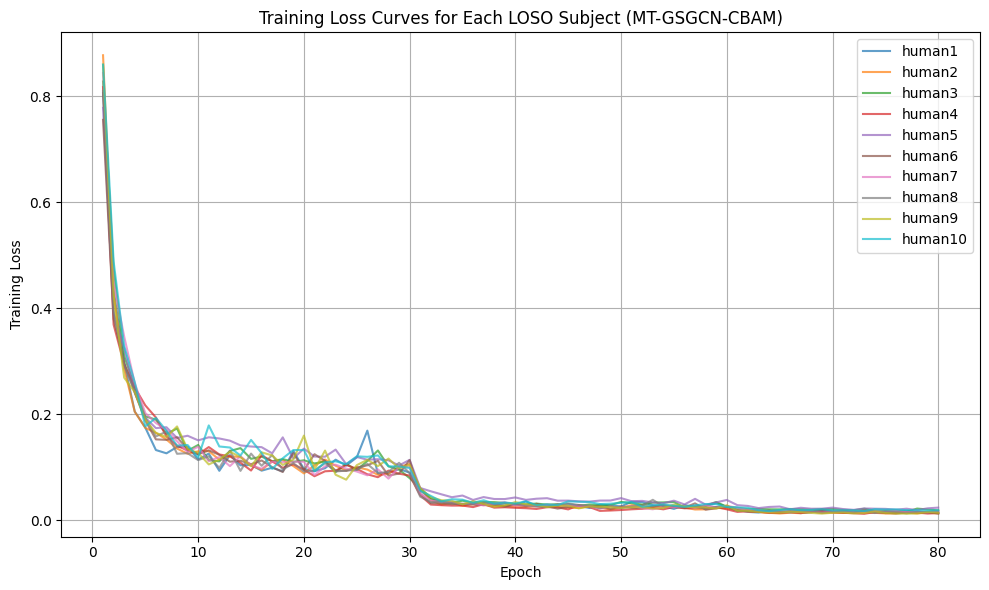

已儲存： .\MT-GSGCN-CBAM\loss_loso_10subjects.png


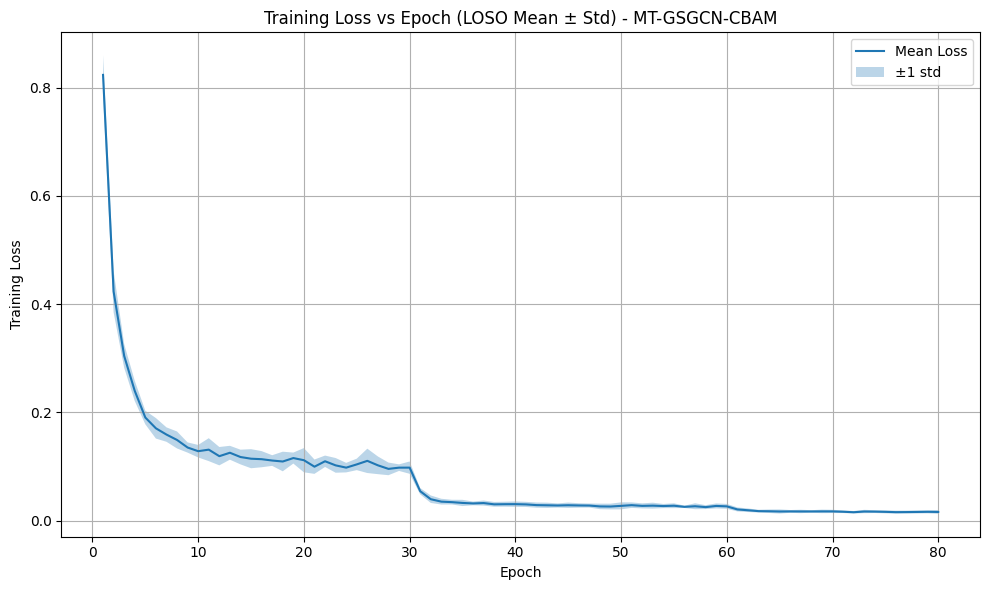

已儲存： .\MT-GSGCN-CBAM\loss_loso_mean_std.png
已儲存： .\MT-GSGCN-CBAM\loss_loso_mean_std.csv
✅ 全部完成。


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os, re

# ============================
#  設定要處理哪個實驗資料夾
# ============================

experiment_name = "MT-GSGCN-CBAM"   # 之後要算 CBAM 就改成 "MT-GSGCN-CBAM"
base_path = os.path.join(".", experiment_name)

print("實驗資料夾：", base_path)

# ============================
#  讀取所有 train_curve_humanX.csv
# ============================

file_paths = sorted(
    glob.glob(os.path.join(base_path, "train_curve_human*.csv")),
    key=lambda x: int(re.search(r"human(\d+)", x).group(1))
)

print("找到檔案：")
for fp in file_paths:
    print("  ", os.path.basename(fp))

if not file_paths:
    raise RuntimeError("找不到任何 train_curve_human*.csv，請確認路徑與檔名。")

all_loss = []
epochs = None

for fp in file_paths:
    df = pd.read_csv(fp)

    # 自動偵測 loss 欄位
    if "loss" in df.columns:
        loss_col = "loss"
    elif "Loss" in df.columns:
        loss_col = "Loss"
    else:
        # 常見格式 [epoch, loss]，就抓第 2 欄
        if len(df.columns) >= 2:
            loss_col = df.columns[1]
        else:
            loss_col = df.columns[0]

    loss_values = df[loss_col].values
    all_loss.append(loss_values)

    # 只在第一次設定 epochs
    if epochs is None:
        if "epoch" in df.columns:
            epochs = df["epoch"].values
        else:
            epochs = np.arange(len(loss_values))

all_loss = np.array(all_loss)
num_folds, num_epochs = all_loss.shape
print(f"Loaded {num_folds} folds, {num_epochs} epochs each.")

# ============================
#  圖片 1：10 subjects loss 曲線
# ============================

plt.figure(figsize=(10, 6))

for i in range(num_folds):
    plt.plot(epochs, all_loss[i], alpha=0.7, label=f"human{i+1}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"Training Loss Curves for Each LOSO Subject ({experiment_name})")
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
out_png1 = os.path.join(base_path, "loss_loso_10subjects.png")
plt.savefig(out_png1, dpi=300)
plt.show()

print("已儲存：", out_png1)

# ============================
#  圖片 2：平均 ± 標準差
# ============================

mean_loss = all_loss.mean(axis=0)
std_loss  = all_loss.std(axis=0)

plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_loss, label="Mean Loss")
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss,
                 alpha=0.3, label="±1 std")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"Training Loss vs Epoch (LOSO Mean ± Std) - {experiment_name}")
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
out_png2 = os.path.join(base_path, "loss_loso_mean_std.png")
plt.savefig(out_png2, dpi=300)
plt.show()

print("已儲存：", out_png2)

# ============================
#  輸出 mean + std CSV（可拿去畫別的圖）
# ============================

df_out = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss
})
out_csv = os.path.join(base_path, "loss_loso_mean_std.csv")
df_out.to_csv(out_csv, index=False)

print("已儲存：", out_csv)
print("✅ 全部完成。")


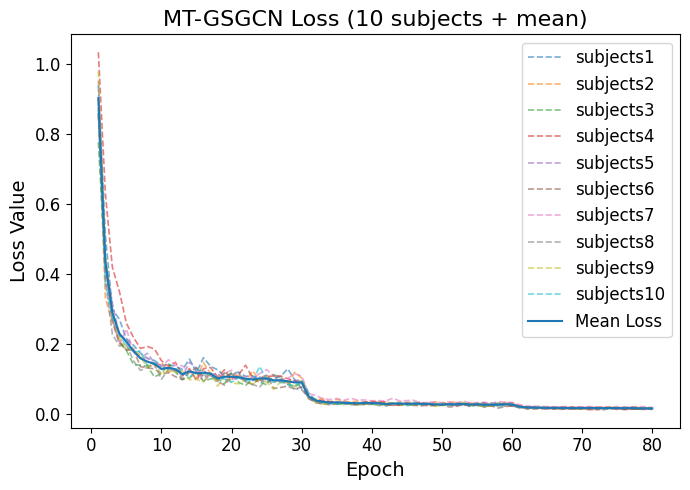

已儲存： .\MT-GSGCN\loss_loso_10subjects_with_mean_clean.png


In [5]:
# ============================
#  圖片 1：10 subjects 虛線 + 平均實線（無背景格線）
# ============================

plt.figure(figsize=(7, 5))

# 畫 10 人虛線
for i in range(num_folds):
    plt.plot(
        epochs, all_loss[i],
        alpha=0.6,
        linestyle='--',
        linewidth=1.2,
        label=f"subjects{i+1}"
    )

# 平均 loss 實線
mean_loss = all_loss.mean(axis=0)

plt.plot(
    epochs, mean_loss,
    color='tab:blue',
    linewidth=1.5,
    label="Mean Loss",
    zorder=10
)

# ======= 文字大小設定 =======
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss Value", fontsize=14)
plt.title(f"{experiment_name} Loss (10 subjects + mean)", fontsize=16)

# 刻度字大小
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 圖例字大小
plt.legend(loc="upper right", fontsize=12)

# ❌ 移除背景線
plt.grid(False)

plt.tight_layout()

out_png1 = os.path.join(base_path, "loss_loso_10subjects_with_mean_clean.png")
plt.savefig(out_png1, dpi=300, transparent=False)
plt.show()

print("已儲存：", out_png1)


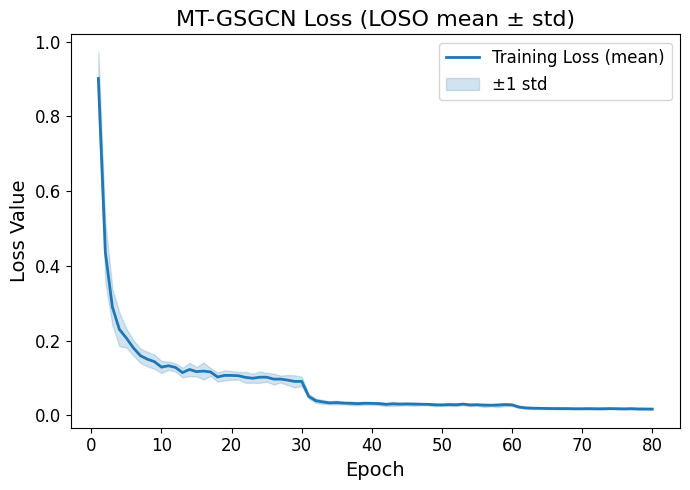

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 假設你已有 all_loss (10 × epochs)
# all_loss = np.array(loss_curves)

epochs = np.arange(1, all_loss.shape[1] + 1)

# 計算平均與標準差
mean_loss = all_loss.mean(axis=0)
std_loss  = all_loss.std(axis=0)

# 畫圖
plt.figure(figsize=(7,5))

plt.plot(
    epochs, mean_loss,
    color='tab:blue',
    linewidth=2.0,
    label="Training Loss (mean)"
)

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    color='tab:blue',
    alpha=0.2,
    label="±1 std"
)

# ===== 字體大小調整 =====
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss Value", fontsize=14)
plt.title("MT-GSGCN Loss (LOSO mean ± std)", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc="upper right", fontsize=12)

# 去背景
plt.grid(False)
plt.tight_layout()

plt.savefig("train_loss_loso_mean_std.png", dpi=300)
plt.show()


實驗資料夾： .\MT-GSGCN-CBAM
找到檔案：
   train_curve_human1.csv
   train_curve_human2.csv
   train_curve_human3.csv
   train_curve_human4.csv
   train_curve_human5.csv
   train_curve_human6.csv
   train_curve_human7.csv
   train_curve_human8.csv
   train_curve_human9.csv
   train_curve_human10.csv
Loaded 10 folds, 80 epochs each.


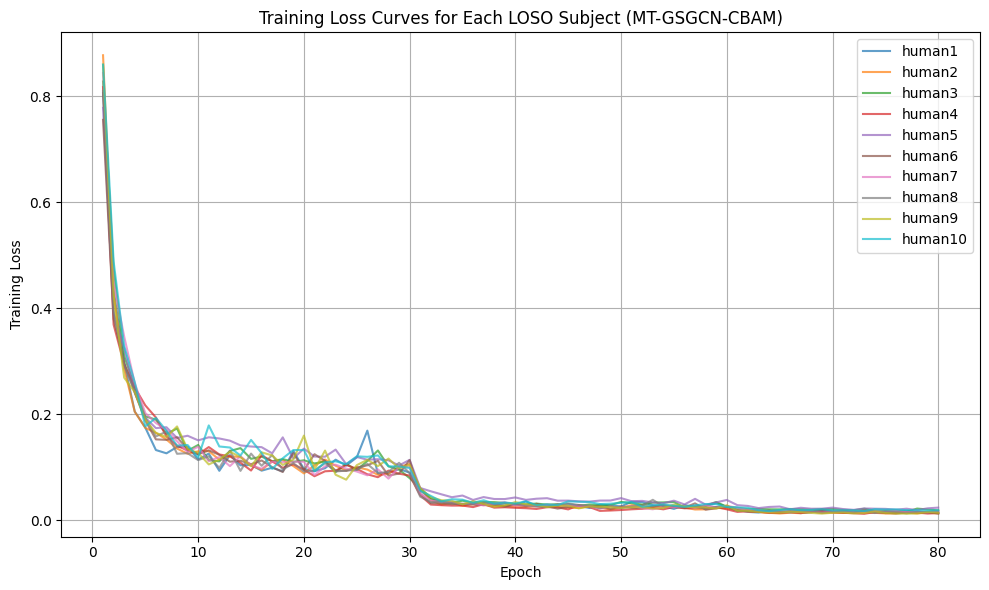

已儲存： .\MT-GSGCN-CBAM\loss_loso_10subjects.png


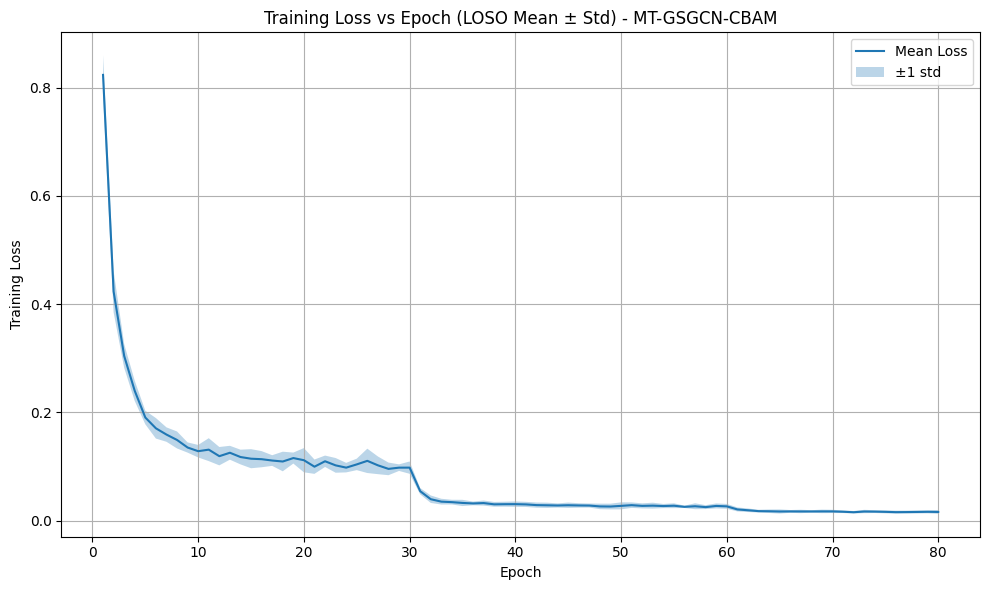

已儲存： .\MT-GSGCN-CBAM\loss_loso_mean_std.png
已儲存： .\MT-GSGCN-CBAM\loss_loso_mean_std.csv
✅ 全部完成。


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os, re

# ============================
#  設定要處理哪個實驗資料夾
# ============================

experiment_name = "MT-GSGCN-CBAM"   # 之後要算 CBAM 就改成 "MT-GSGCN-CBAM"
base_path = os.path.join(".", experiment_name)

print("實驗資料夾：", base_path)

# ============================
#  讀取所有 train_curve_humanX.csv
# ============================

file_paths = sorted(
    glob.glob(os.path.join(base_path, "train_curve_human*.csv")),
    key=lambda x: int(re.search(r"human(\d+)", x).group(1))
)

print("找到檔案：")
for fp in file_paths:
    print("  ", os.path.basename(fp))

if not file_paths:
    raise RuntimeError("找不到任何 train_curve_human*.csv，請確認路徑與檔名。")

all_loss = []
epochs = None

for fp in file_paths:
    df = pd.read_csv(fp)

    # 自動偵測 loss 欄位
    if "loss" in df.columns:
        loss_col = "loss"
    elif "Loss" in df.columns:
        loss_col = "Loss"
    else:
        # 常見格式 [epoch, loss]，就抓第 2 欄
        if len(df.columns) >= 2:
            loss_col = df.columns[1]
        else:
            loss_col = df.columns[0]

    loss_values = df[loss_col].values
    all_loss.append(loss_values)

    # 只在第一次設定 epochs
    if epochs is None:
        if "epoch" in df.columns:
            epochs = df["epoch"].values
        else:
            epochs = np.arange(len(loss_values))

all_loss = np.array(all_loss)
num_folds, num_epochs = all_loss.shape
print(f"Loaded {num_folds} folds, {num_epochs} epochs each.")

# ============================
#  圖片 1：10 subjects loss 曲線
# ============================

plt.figure(figsize=(10, 6))

for i in range(num_folds):
    plt.plot(epochs, all_loss[i], alpha=0.7, label=f"human{i+1}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"Training Loss Curves for Each LOSO Subject ({experiment_name})")
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
out_png1 = os.path.join(base_path, "loss_loso_10subjects.png")
plt.savefig(out_png1, dpi=300)
plt.show()

print("已儲存：", out_png1)

# ============================
#  圖片 2：平均 ± 標準差
# ============================

mean_loss = all_loss.mean(axis=0)
std_loss  = all_loss.std(axis=0)

plt.figure(figsize=(10, 6))

plt.plot(epochs, mean_loss, label="Mean Loss")
plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss,
                 alpha=0.3, label="±1 std")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(f"Training Loss vs Epoch (LOSO Mean ± Std) - {experiment_name}")
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
out_png2 = os.path.join(base_path, "loss_loso_mean_std.png")
plt.savefig(out_png2, dpi=300)
plt.show()

print("已儲存：", out_png2)

# ============================
#  輸出 mean + std CSV（可拿去畫別的圖）
# ============================

df_out = pd.DataFrame({
    "epoch": epochs,
    "mean_loss": mean_loss,
    "std_loss": std_loss
})
out_csv = os.path.join(base_path, "loss_loso_mean_std.csv")
df_out.to_csv(out_csv, index=False)

print("已儲存：", out_csv)
print("✅ 全部完成。")


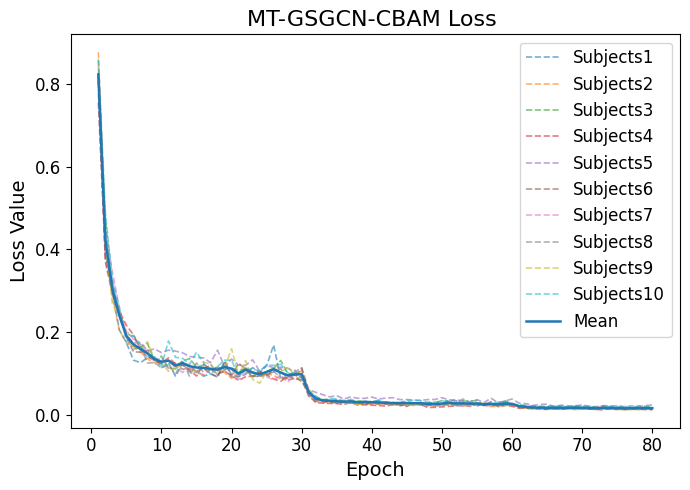

已儲存： .\MT-GSGCN-CBAM\loss_loso_10subjects_with_mean_clean.png


In [11]:
# ============================
#  圖片 1：10 subjects 虛線 + 平均實線（無背景格線）
# ============================

plt.figure(figsize=(7, 5))

# 畫 10 人虛線
for i in range(num_folds):
    plt.plot(
        epochs, all_loss[i],
        alpha=0.6,
        linestyle='--',
        linewidth=1.2,
        label=f"Subjects{i+1}"
    )

# 平均 loss 實線
mean_loss = all_loss.mean(axis=0)

plt.plot(
    epochs, mean_loss,
    color='tab:blue',   # Matplotlib 預設藍色
    linewidth=1.8,
    label="Mean",
    zorder=10
)

# ===== 字體大小調整 =====
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss Value", fontsize=14)
plt.title(f"{experiment_name} Loss ", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc="upper right", fontsize=12)

# 移除背景格線
plt.grid(False)

plt.tight_layout()

out_png1 = os.path.join(base_path, "loss_loso_10subjects_with_mean_clean.png")
plt.savefig(out_png1, dpi=300, transparent=False)
plt.show()

print("已儲存：", out_png1)


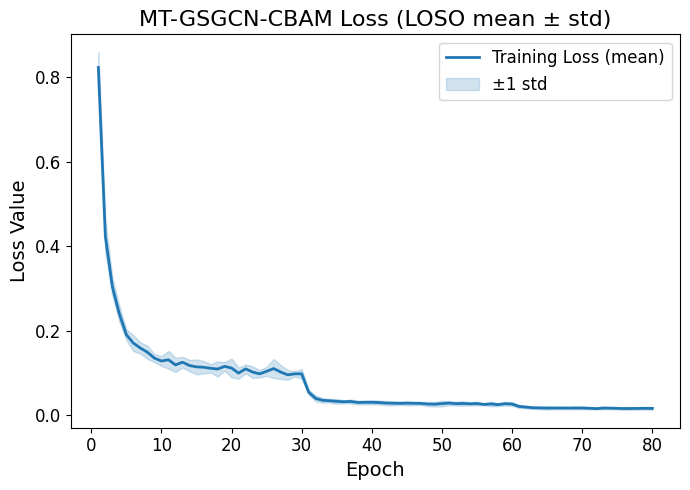

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 假設你已有 all_loss (10 × epochs)
# all_loss = np.array(loss_curves)

epochs = np.arange(1, all_loss.shape[1] + 1)

# 計算平均與標準差
mean_loss = all_loss.mean(axis=0)
std_loss  = all_loss.std(axis=0)

# 畫圖
plt.figure(figsize=(7,5))

plt.plot(
    epochs, mean_loss,
    color='tab:blue',           
    linewidth=2.0,
    label="Training Loss (mean)"
)

plt.fill_between(
    epochs,
    mean_loss - std_loss,
    mean_loss + std_loss,
    color='tab:blue',
    alpha=0.2,
    label="±1 std"
)

# ===== 字體放大 =====
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss Value", fontsize=14)
plt.title("MT-GSGCN-CBAM Loss (LOSO mean ± std)", fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(loc="upper right", fontsize=12)

plt.grid(False)
plt.tight_layout()

plt.savefig("train_loss_loso_mean_std.png", dpi=300)
plt.show()
